In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import os
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.applications.inception_v3 import InceptionV3

In [ ]:
# Veri yolu ve parametreleri
train_data = '/content/drive/MyDrive/TomatoDisease/Dataset/train'
test_data = '/content/drive/MyDrive/TomatoDisease/Dataset/test'
img_width, img_height = 224, 224
batch_size = 32
num_classes = 10

In [ ]:
# Veri ön işleme ve artırma
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True)

test_generator = test_datagen.flow_from_directory(
    test_data,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False)

Found 18365 images belonging to 10 classes.
Found 4605 images belonging to 10 classes.


In [ ]:
# InceptionV3 Modeli
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))

# Yeni modeli oluşturma
model = tf.keras.models.Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

# Modeli derleme
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

87910968/87910968 [==============================] - 1s 0us/step


In [ ]:
history = model.fit(train_generator, epochs=10, validation_data=test_generator, use_multiprocessing=True, workers = 64)

Epoch 1/10


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


574/574 [==============================] - 682s 1s/step - loss: 0.5227 - accuracy: 0.8415 - val_loss: 3.3400 - val_accuracy: 0.4723
Epoch 2/10
574/574 [==============================] - 81s 135ms/step - loss: 0.2440 - accuracy: 0.9250 - val_loss: 0.3966 - val_accuracy: 0.8760
Epoch 3/10
574/574 [==============================] - 81s 135ms/step - loss: 0.1879 - accuracy: 0.9432 - val_loss: 0.7594 - val_accuracy: 0.8041
Epoch 4/10
574/574 [==============================] - 83s 137ms/step - loss: 0.1621 - accuracy: 0.9485 - val_loss: 0.4769 - val_accuracy: 0.8630
Epoch 5/10
574/574 [==============================] - 81s 135ms/step - loss: 0.1582 - accuracy: 0.9513 - val_loss: 0.2106 - val_accuracy: 0.9390
Epoch 6/10
574/574 [==============================] - 85s 141ms/step - loss: 0.1133 - accuracy: 0.9666 - val_loss: 0.4129 - val_accuracy: 0.8890
Epoch 7/10
574/574 [==============================] - 85s 141ms/step - loss: 0.1125 - accuracy: 0.9667 - val_loss: 0.4640 - val_accuracy: 0.881

In [ ]:
test_steps_per_epoch = np.ceil(test_generator.samples / test_generator.batch_size)

test_loss, test_accuracy = model.evaluate(test_generator, steps=test_steps_per_epoch)
print(f'Test Doğruluğu: {test_accuracy * 100:.2f}%')

144/144 [==============================] - 16s 108ms/step - loss: 0.1806 - accuracy: 0.9464
Test Doğruluğu: 94.64%


In [ ]:
predIdx=model.predict(test_generator)
pred=np.argmax(predIdx,axis=1)

144/144 [==============================] - 16s 104ms/step


In [ ]:
print(classification_report(test_generator.classes,pred))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88       425
           1       0.95      0.95      0.95       480
           2       0.99      0.90      0.95       463
           3       1.00      0.94      0.97       470
           4       0.96      0.89      0.92       436
           5       1.00      0.88      0.94       445
           6       0.86      0.95      0.90       457
           7       0.99      0.96      0.98       490
           8       1.00      0.99      0.99       458
           9       0.98      1.00      0.99       481

    accuracy                           0.95      4605
   macro avg       0.95      0.95      0.95      4605
weighted avg       0.95      0.95      0.95      4605



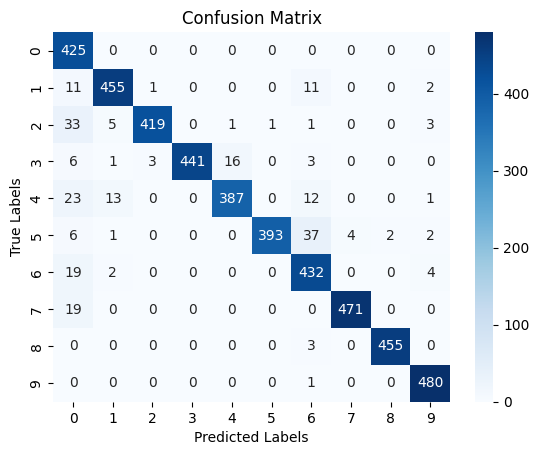

In [ ]:
import seaborn as sns
cm = confusion_matrix(test_generator.classes, pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


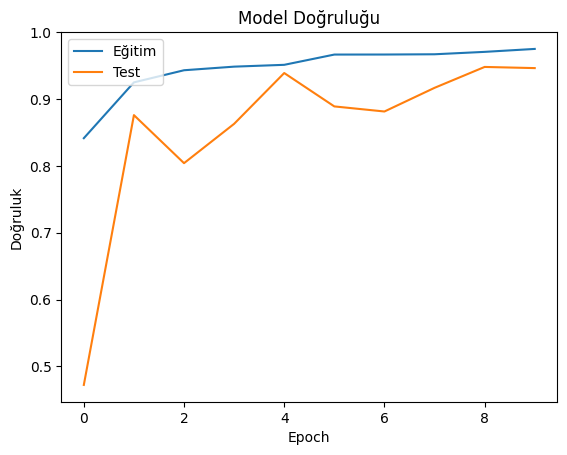

In [ ]:
# Doğruluk oranını çizme
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Doğruluğu')
plt.ylabel('Doğruluk')
plt.xlabel('Epoch')
plt.legend(['Eğitim', 'Test'], loc='upper left')
plt.show()